In [ ]:
import xarray as xr
import zarr
import pandas as pd

from pyproj import CRS
from cartopy import crs as ccrs
from pyproj import Proj, itransform
from pyproj import Transformer

import matplotlib.pyplot as plt

In [ ]:
PATH_TO_FORECAST = "/path/to/dini"
PATH_TO_NOWCAST = "/path/to/nowcast"
PATH_TO_OBS = "/path/to/obs"

In [35]:
#open a forecast
ds = xr.open_dataset(PATH_TO_FORECAST, consolidated=True, engine="zarr")
forecast = ds.sel(forecast_reference_time="2025-07-15T12:00:00", method="nearest")
forecast

<xarray.Dataset> Size: 343MB
Dimensions:                  (step: 12, y: 1606, x: 1906)
Coordinates:
  * step                     (step) timedelta64[us] 96B 00:00:00 ... 11:00:00
  * y                        (y) float64 13kB -1.589e+06 ... 1.621e+06
  * x                        (x) float64 15kB -1.528e+06 ... 2.282e+06
    latitude                 (y, x) float64 24MB ...
    longitude                (y, x) float64 24MB ...
    forecast_reference_time  datetime64[ns] 8B 2025-07-15T12:00:00
Data variables:
    dini_projection          float64 8B ...
    grad                     (step, y, x) float64 294MB ...
Attributes:
    institution:  DMI
    Conventions:  CF-1.8

In [ ]:
#open a nowcast
ds = xr.open_dataset(PATH_TO_NOWCAST)
nowcast = ds.probabilistic_advection.sel(ensemble=0)
nowcast

<xarray.DataArray 'probabilistic_advection' (time: 25, lat: 368, lon: 713)> Size: 52MB
[6559600 values with dtype=float64]
Coordinates:
  * time      (time) datetime64[ns] 200B 2025-07-15T12:00:00 ... 2025-07-15T1...
  * lat       (lat) float64 3kB 63.48 63.43 63.39 63.35 ... 47.36 47.32 47.27
  * lon       (lon) float64 6kB -10.73 -10.69 -10.64 -10.6 ... 19.89 19.94 19.98
    ensemble  int32 4B 0
Attributes:
    description:  Probabilistic advection solar forecast
    long_name:    Surface downwelling solar radiation
    units:        W m-2

<Axes: xlabel='TmStamp'>

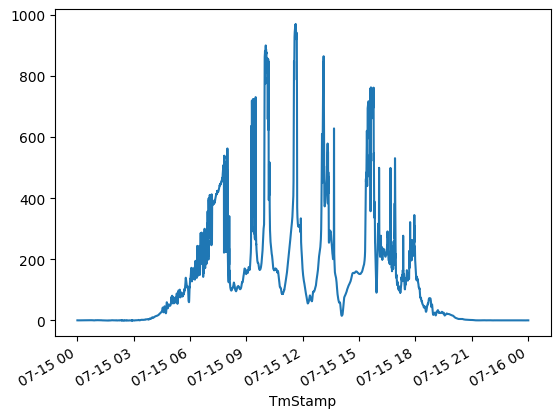

In [ ]:
#open pyranometer measurements 
df = pd.read_csv(PATH_TO_OBS)
#ensure datetime format and set index
df['TmStamp'] = pd.to_datetime(df['TmStamp'])
df = df.set_index('TmStamp')

#select a specific time window
pyranometer = df['2025-07-15 00:00':'2025-07-16 00:00']

#plot pyranometer measurements
pyranometer['Global_Horizontal_Pyr'].plot()

In [29]:
#select a point in the forecast and plot
wkt = forecast.dini_projection.attrs["crs_wkt"]

dini_proj = ccrs.Projection(CRS.from_wkt(wkt))
trans = Transformer.from_crs(ccrs.PlateCarree(), dini_proj, always_xy=True)

lon_lat = 12.101793, 55.694243

xy_point = trans.transform(lon_lat[0], lon_lat[1])
dini_point = forecast.sel(x=xy_point[0], y=xy_point[1], method="nearest")


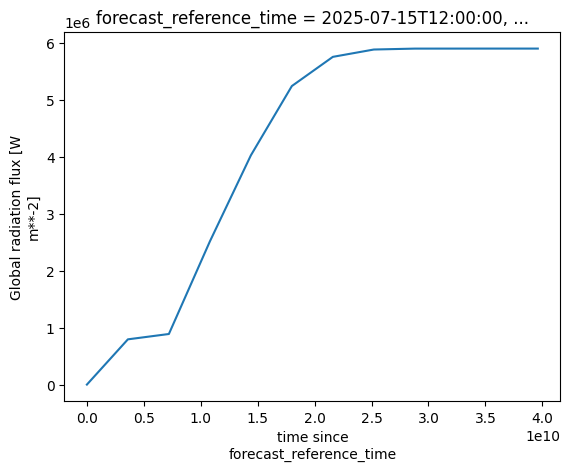

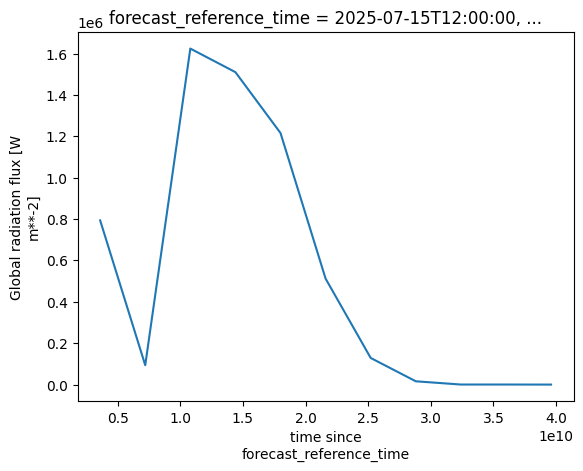

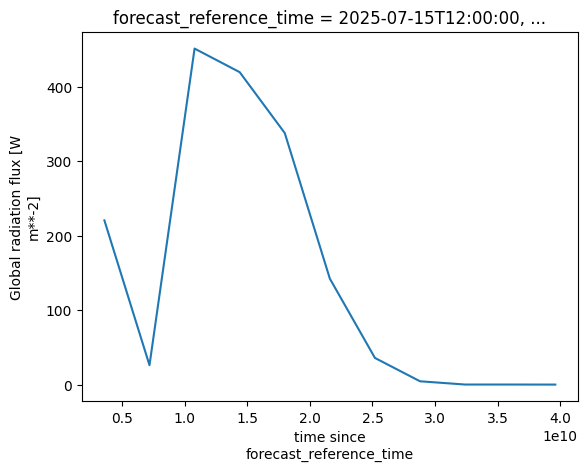

In [32]:
#plot the values for the point
dini_point.grad.plot()
plt.show()
#the values are accumulated! We want to see the hourly values, so we need to take the difference
dini_hourly = dini_point.diff("step")
dini_hourly.grad.plot()
plt.show()
#we need to divide by 3600 to get from Wh to W, since the pyranometer measurements are in W/m2 and the forecast is in Wh/m2
dini_hourly_GHI = dini_hourly.grad / 3600
dini_hourly_GHI.plot()

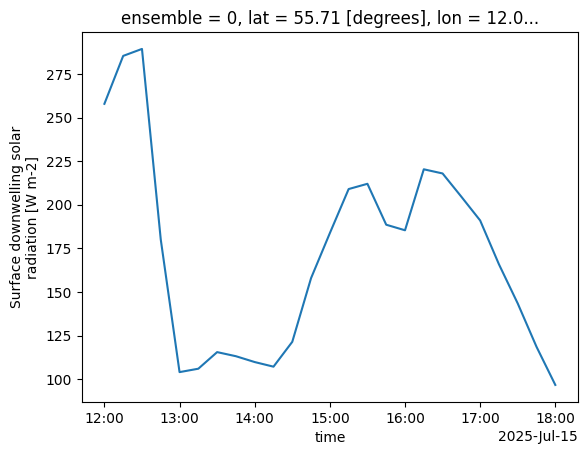

In [26]:
#plot nowcast at the same point
nowcast_point = nowcast.sel(lon=lon_lat[0], lat=lon_lat[1], method="nearest")
nowcast_point.plot()